In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

                                        ***One Hot Encoding | Handling Categorical Data***

One-hot encoding is used with nominal input data and we are discussing the "Dummay Variable Trap" in this, we are using reducing one column from date.

#multicolinearity me input column me koi relationship nahi hona chahiye.but in the below table, we are getting Sum=1+0+0=1 There is a relation, so we are using "Dummay Variable trap" to reduce multicolinearity and it is impacting if you are working on a linear model.

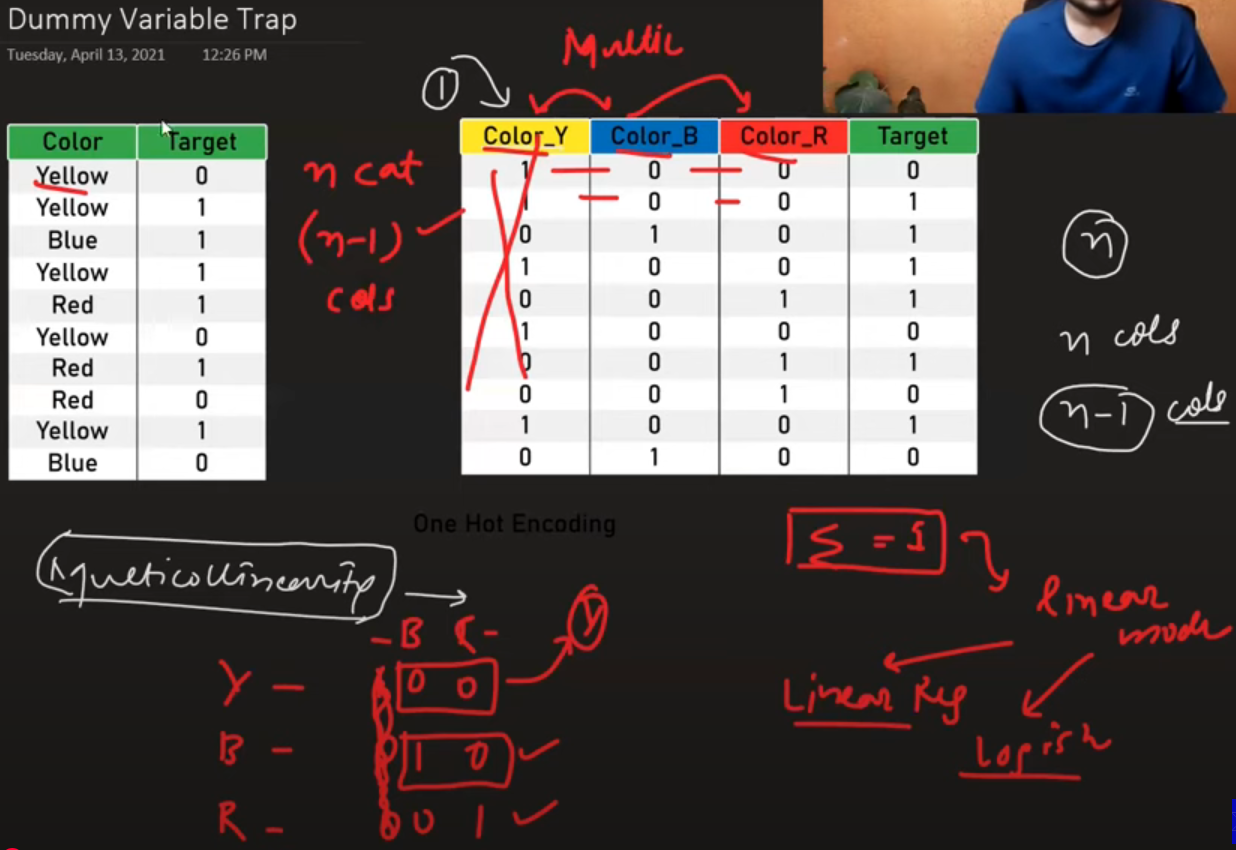

In [4]:
from IPython.display import Image
Image(filename = "C:/Users/Admin/Desktop/ML Practice/ML_100_Day Data/Pic/Dummy_Variable_Trap.PNG")

In [6]:
df=pd.read_csv(r"C:\Users\Admin\Desktop\ML Practice\ML_100_Day Data/Data/cars.csv")
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [7]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

1. OneHotEncoding using Pandas

In [8]:
pd.get_dummies(df,columns=['fuel','owner'])

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


2. K-1 OneHotEncoding

In [9]:
pd.get_dummies(df,columns=['fuel','owner'],drop_first=True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


3. OneHotEncoding using Sklearn

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size=0.2,random_state=2)

In [11]:
X_train.head()

,brand,km_driven,fuel,owner
5571,Hyundai,35000,Diesel,First Owner
2038,Jeep,60000,Diesel,First Owner
2957,Hyundai,25000,Petrol,First Owner
7618,Mahindra,130000,Diesel,Second Owner
6684,Hyundai,155000,Diesel,First Owner


In [15]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop='first',dtype=np.int32)

In [16]:
X_train_new = ohe.fit_transform(X_train[['fuel','owner']])

In [17]:
X_test_new = ohe.transform(X_test[['fuel','owner']])

In [18]:
X_train_new.shape

(6502, 7)

In [20]:
#is using NumPy's hstack to horizontally stack two arrays:
np.hstack((X_train[['brand','km_driven']].values,X_train_new))

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

4. OneHotEncoding with Top Categories

In [21]:
counts = df['brand'].value_counts()

In [22]:
df['brand'].nunique()
threshold = 100

In [23]:
repl = counts[counts <= threshold].index

In [24]:
pd.get_dummies(df['brand'].replace(repl, 'uncommon')).sample(5)

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
7684,False,True,False,False,False,False,False,False,False,False,False,False,False
1399,False,False,False,False,False,False,False,False,False,False,True,False,False
1196,False,False,False,False,False,False,True,False,False,False,False,False,False
2512,False,False,True,False,False,False,False,False,False,False,False,False,False
2667,False,False,False,False,False,False,False,False,False,False,False,False,True


# Here data is reflecting true & False instead of 0 and 1.